# Project 1: Data Analysis Project 

In [49]:
# a. Importing packages and setting up the formatting of figures. 

import numpy as np
import pandas as pd

# b. Importing API packages 
from fredapi import Fred
from dstapi import DstApi

# c. Importing packages for plotting and setting up the formatting of figures 
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# PROBLEM 1 - Income Inequality and Gini Coefficient

**PROBLEM 1: Inequality in Denmark**

In [50]:
# a. data import and overview of variables in table IFOR41
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [51]:
# Finding the appropriate variable (Gini coefficient) levels for the variable ULLIG in table IFOR41.
IFOR41.variable_levels('ULLIG',language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [52]:
# a. Setting parameters for the gini coefficient for all of denmark  
params = {
    'table': 'IFOR41',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}, # '*' is everything
        ]
    }

# b. downloading the gini coefficient for all of denmark
gini = IFOR41.get_data(params=params)


# c. displaying the output in a table format
display(gini.head(5))
display(gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ULLIG      38 non-null     str  
 1   KOMMUNEDK  38 non-null     str  
 2   TID        38 non-null     int64
 3   INDHOLD    38 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.5 KB


None

In [53]:
# a. Calling the data function to load the gini coefficient for all of denmark
from data_loader import load_IFOR41

# d. Calling the funtion with the appropriate parameter values to load the gini coefficient for all of denmark
gini_df = load_IFOR41('70', '000', '*')

# e. displaying the first 5 yearly values of the gini coefficient for all of denmark
print(gini_df.head())

     KOMMUNEDK  year   gini
0  All Denmark  1987  22.07
1  All Denmark  1988  22.06
2  All Denmark  1989  21.93
3  All Denmark  1990  22.16
4  All Denmark  1991  21.99


In [54]:
# Loading data from the IFOR32 table 
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [55]:
# a. Calling the data function to load the income shares for the top 10 pct.
from data_loader import load_IFOR32

# g. Calling the funtion with the appropriate parameter values 
income_10pct = load_IFOR32('*', '000', '*')

# h. displaying the first 5 yearly values of the top 10% income share for all of denmark
print(income_10pct.head())

     KOMMUNEDK  year  top_10_share
0  All Denmark  1987      0.184549
1  All Denmark  1988      0.184289
2  All Denmark  1989      0.184952
3  All Denmark  1990      0.186415
4  All Denmark  1991      0.186683


In [56]:
import pandas as pd

# a. combining the two DataFrames on year (index)
df_merged = pd.merge(gini_df, income_10pct, left_index=True, right_index=True, validate='1:1')

# b. computing the correlation between the two inequality measures
correlation = df_merged['gini'].corr(df_merged['top_10_share'])

print(f"Correlation is: {correlation:.4f}")

Correlation is: 0.9816


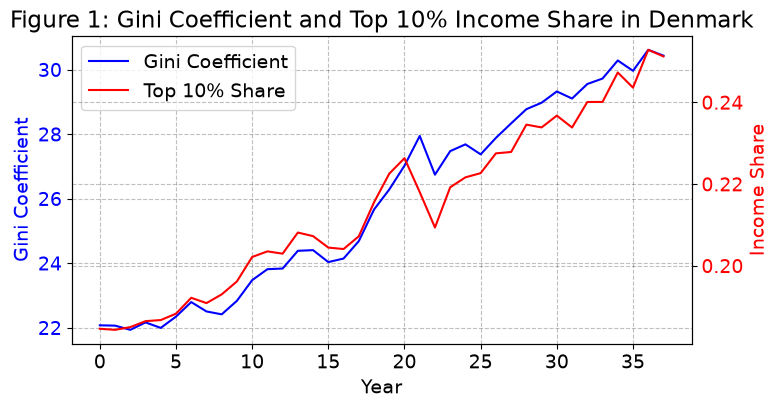

In [57]:
import matplotlib.pyplot as plt

# a. Creating a figure and primary axis for the Gini coefficient
fig, ax1 = plt.subplots(figsize=(8, 4))

# b. Plotting Gini coefficient on the left y-axis
ax1.plot(df_merged.index, df_merged['gini'], color='blue', label='Gini Coefficient')
ax1.set_xlabel('Year')
ax1.set_ylabel('Gini Coefficient', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# c. Creating secondary axis and plot top 10% income share on the right y-axis
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged['top_10_share'], color='red', label='Top 10% Share')
ax2.set_ylabel('Income Share', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# d. Combining legends from both axes and display the plot
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Figure 1: Gini Coefficient and Top 10% Income Share in Denmark')
plt.show()

**Comparison of the two inequality meassures for Denmark since 1987**

Figure 1 and 2 display the same overall upward trend for inequality in Denmark since 1987. Figure 1 show an increasing gini coefficient indicating an increasing income inequality. The same is evident from figure 2 which dispaly how the top 10 income decile have increased thier income share and thus there is now a higher wealth distribution amongst the top earners. With a correlation of 0.9816 the thwo meassures have a very high correlation. The main difference is that the dip in 2008 is more pornounced in figure 2 which indicate that the highest earnes had a big drop in income due to the financial crisis. 

**1.2) Prediction of the Gini coefficient** 

In [58]:
#Importing minimize tool
from scipy.optimize import minimize

# a. setting up variables for the minimization problem
# ai. Sorting observations by year. 
gini = gini.sort_values('TID').copy()

# aii. Creating variable y_i: observed Gini coefficient
y = gini['INDHOLD'].astype(float).to_numpy() # Using the data set made in cell 5 to use all the Gini Coefficients, where we make them as floats.

# aiii. Creating variable t_i: number of years since 1987
t = gini['TID'].astype(int).to_numpy() - 1987

# b. Defining the minimization problem using the least squared method and defining the objective function
def leastsquares(beta, t, y):
    """ Calculates sum of squared errors for polynomial trend.
    
    Args:
        beta (list): Coefficients.
        t (np.array): Time array.
        y (np.array): Observed values.
        
    Returns:
        float: Sum of squared errors.
    """
    y_hat = sum(beta[k] * t**k for k in range(len(beta)))
    
    return np.sum((y - y_hat)**2)

# c. Linear trend estimation , p = 1
beta0_linear = np.zeros(2) #np.zeros(2) is used as the start guesses for the beta parameters of the linear model. 
result_linear = minimize(
    leastsquares,
    beta0_linear,
    args=(t, y)
)

beta_linear = result_linear.x
beta_0_linear, beta_1_linear = beta_linear

print(f"Linear model:")
print(f"beta_0 = {beta_0_linear:.4f}")
print(f"beta_1 = {beta_1_linear:.4f}")

# d. Quadratic trend estimation , p = 2
beta0_quadratic = np.zeros(3) #np.zeros(3) is used as the start guesses for the beta parameters of the quadratic model. 
result_quadratic = minimize(
    leastsquares,
    beta0_quadratic,
    args=(t, y)
)

beta_quadratic = result_quadratic.x
beta_0_quadratic, beta_1_quadratic, beta_2_quadratic = beta_quadratic

print(f"Quadratic model:")
print(f"beta_0 = {beta_0_quadratic:.4f}")
print(f"beta_1 = {beta_1_quadratic:.4f}")
print(f"beta_2 = {beta_2_quadratic:.6f}")

Linear model:
beta_0 = 21.0428
beta_1 = 0.2635
Quadratic model:
beta_0 = 21.3042
beta_1 = 0.2200
beta_2 = 0.001178


In [59]:
# a. Checking the linear model with np.polyfit
polyfit_linear = np.polyfit(t, y, 1)
polyfit_linear = polyfit_linear[::-1] #Reversing the order to get beta_0, beta_1

print("Linear model:")
print(f"minimize: beta_0 = {beta_linear[0]:.4f}, beta_1 = {beta_linear[1]:.4f}")
print(f"polyfit:  beta_0 = {polyfit_linear[0]:.4f}, beta_1 = {polyfit_linear[1]:.4f}")

# b. checking quadratic model with np.polyfit
polyfit_quadratic = np.polyfit(t, y, 2)
polyfit_quadratic = polyfit_quadratic[::-1]

print("Quadratic model:")
print(f"minimize: beta_0 = {beta_quadratic[0]:.4f}, beta_1 = {beta_quadratic[1]:.4f}, beta_2 = {beta_quadratic[2]:.6f}")
print(f"polyfit:  beta_0 = {polyfit_quadratic[0]:.4f}, beta_1 = {polyfit_quadratic[1]:.4f}, beta_2 = {polyfit_quadratic[2]:.6f}")

Linear model:
minimize: beta_0 = 21.0428, beta_1 = 0.2635
polyfit:  beta_0 = 21.0428, beta_1 = 0.2635
Quadratic model:
minimize: beta_0 = 21.3042, beta_1 = 0.2200, beta_2 = 0.001178
polyfit:  beta_0 = 21.3042, beta_1 = 0.2200, beta_2 = 0.001178


Linear predictions: [32.37538611 35.01088205]
Quadratic predictions: [32.94067063 36.27099718]


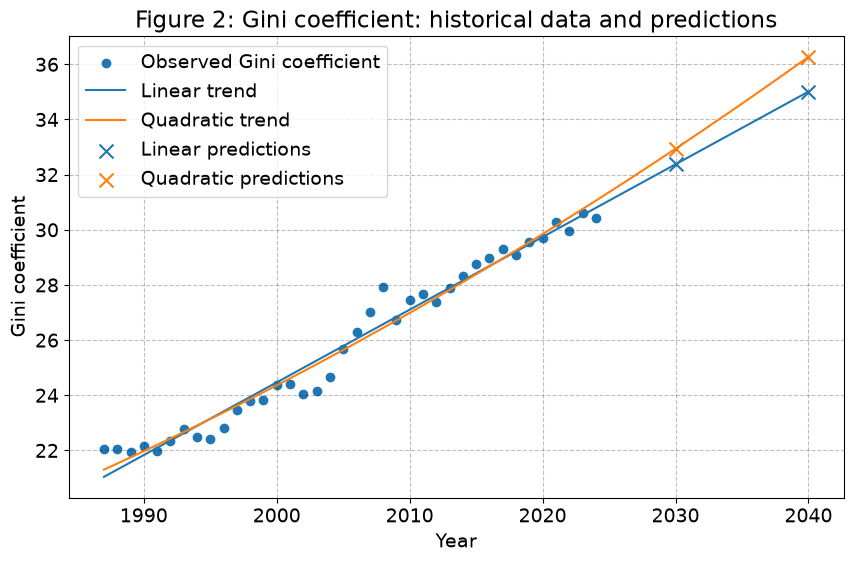

R² linear model:    0.9707
R² quadratic model: 0.9725


In [60]:
###Calculating the predicted values for the years 2030 and 2040 using both the linear and quadratic models.

# a. setup of future years
years_predict = np.array([2030, 2040])
t_predict = years_predict - 1987

# b. calculating linear- quadratic predictions
pred_linear = (
    beta_linear[0]
    + beta_linear[1] * t_predict
)

pred_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_predict
    + beta_quadratic[2] * t_predict**2
)

print("Linear predictions:", pred_linear)
print("Quadratic predictions:", pred_quadratic)

# c. defining x and y-values for the trend lines (i.e., from historical start to 2040)
years_plot = np.arange(1987, 2041) 
t_plot = years_plot - 1987

y_linear = (
    beta_linear[0] 
    + beta_linear[1] * t_plot
)

y_quadratic = (
    beta_quadratic[0] 
    + beta_quadratic[1] * t_plot 
    + beta_quadratic[2] * t_plot**2
)

# d. Plotting the predicted values with the historical values as well.
plt.figure(figsize=(10, 6))


plt.scatter(
    gini['TID'].astype(int),
    y,
    label='Observed Gini coefficient'
)

linear_line, = plt.plot(
    years_plot,
    y_linear,
    label='Linear trend'
)

quadratic_line, = plt.plot(
    years_plot,
    y_quadratic,
    label='Quadratic trend'
)

# di. Linear predictions
plt.scatter(
    years_predict,
    pred_linear,
    marker='x',
    s=100,
    color=linear_line.get_color(),
    label='Linear predictions'
)

# dii. Quadratic predictions
plt.scatter(
    years_predict,
    pred_quadratic,
    marker='x',
    s=100,
    color=quadratic_line.get_color(),
    label='Quadratic predictions'
)
# e. Adding labels and title to the plot 
plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 2: Gini coefficient: historical data and predictions')
plt.legend()

plt.show()

###Calculating how fitting the two specifications fit the historical data. 

# f. Finding the fitted values for historical observations
y_hat_linear = (
    beta_linear[0]
    + beta_linear[1] * t
)

y_hat_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)
# g. Calculating the R² for both models
def r_squared(y, y_hat):
    
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    return 1 - ss_res / ss_tot

r2_linear = r_squared(y, y_hat_linear)
r2_quadratic = r_squared(y, y_hat_quadratic)

print(f"R² linear model:    {r2_linear:.4f}")
print(f"R² quadratic model: {r2_quadratic:.4f}")


Results:

We get the same beta coefficients for both the lienar and the quadratic trend, when using the scipy.optimize.minimize and the np.polyfit tools. 

We see that the quadratic model predicts a larger Gini coefficient compared to that of the linear model. We see that the relative difference between the two models gets bigger the further into the future. 

We see that the predictions for both the linear and the quadratic predictions does not visibly fit the observed values that well. However, the R-squarred value is relatively large, which indicates a great fit. It is larger for the quadratic model, which we would also have expected. 

One should be careful to trust this prediction, since this model only accounts for the actual Gini coefficient. There are many other explanatory variables, that must be taken into consideration. 

**Problem 1.3**

1.3.1:
Computing the correlation across municipalities between the gini coefficient and the top 10 pct. share. 

In [61]:
# a. Getting the data for all municipalities to create the table
gini_df = load_IFOR41('70', '*', '*')
income_10pct = load_IFOR32('*', '*', '*')

gini_df = gini_df[gini_df['KOMMUNEDK'] != '000']
income_10pct = income_10pct[income_10pct['KOMMUNEDK'] != '000']

# b. Merging the tables into a single dataset
df_samlet = pd.merge(gini_df, income_10pct, on=['KOMMUNEDK', 'year'], how='inner', validate='1:1')

# c. displaying the first 5 rows of the merged dataset
print(df_samlet.head())

  KOMMUNEDK  year   gini  top_10_share
0  Aabenraa  1987  21.33      0.183458
1  Aabenraa  1988  21.51      0.182620
2  Aabenraa  1989  20.74      0.181198
3  Aabenraa  1990  20.83      0.182724
4  Aabenraa  1991  20.86      0.185529


Correlation is: 0.9605
Correlation is: 0.9605


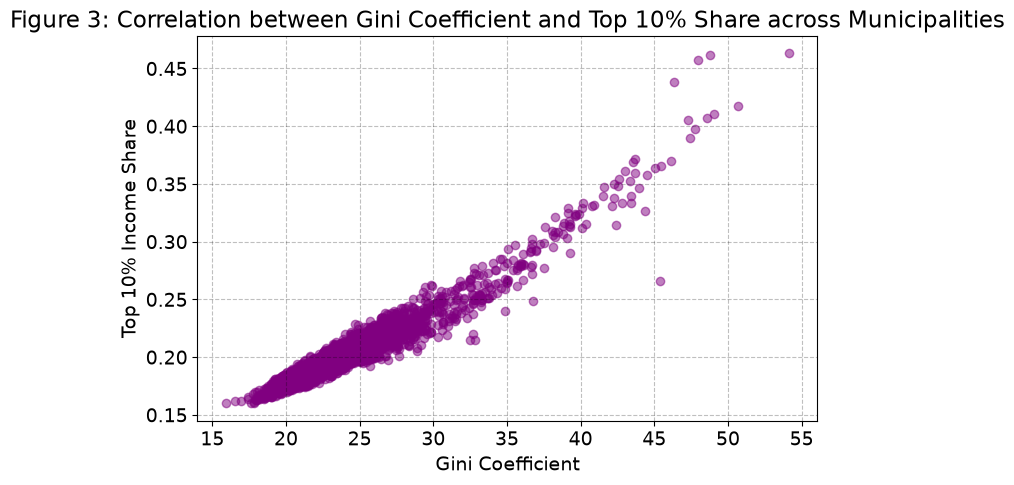

In [62]:
# a. Computing the correlation between the two inequality measures for all municipalities in Denmark.
correlation = df_samlet['gini'].corr(df_samlet['top_10_share'])
print(f"Correlation is: {correlation:.4f}")

# a. Compute the correlation between the two inequality measures across municipalities
correlation = df_samlet['gini'].corr(df_samlet['top_10_share'])
print(f"Correlation is: {correlation:.4f}")

# b. Create a scatterplot to illustrate the correlation
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# i. Plotting municipal observations
ax.scatter(df_samlet['gini'], df_samlet['top_10_share'], alpha=0.5, color='purple')

# ii. Adding labels, title, and formatting
ax.set_title('Figure 3: Correlation between Gini Coefficient and Top 10% Share across Municipalities')
ax.set_xlabel('Gini Coefficient')
ax.set_ylabel('Top 10% Income Share')

plt.show()

We see that the correlation between the thwo meassures is a bit lower than the 0.9816 found in 1.2 but the difference is miniscule so the correlation is still very strong at 0.9605. 

1.3.2

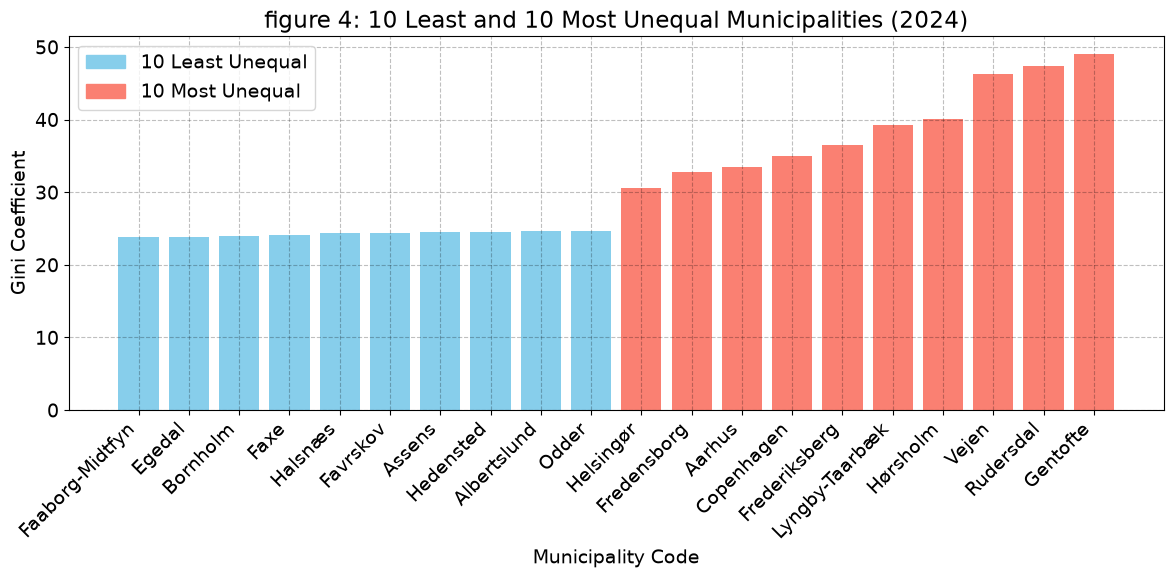

In [63]:
import matplotlib.patches as mpatches # Import for creating custom legend handles

# a. filter the dataset by last year
last_year = df_samlet['year'].max()
df_last_year = df_samlet[df_samlet['year'] == last_year]

# b. sorting and extract the 10 least unequal (lowest Gini) and 10 most unequal (highest Gini)
df_sorted = df_last_year.sort_values('gini')
bottom_10 = df_sorted.head(10)
top_10 = df_sorted.tail(10)

# c. Combining the two DataFrames for plotting
df_plot = pd.concat([bottom_10, top_10])

# d. Creating the bar chart
plt.figure(figsize=(12, 6))
colors = ['skyblue']*10 + ['salmon']*10
plt.bar(df_plot['KOMMUNEDK'], df_plot['gini'], color=colors)

# e. Creating and adding the legend
least_patch = mpatches.Patch(color='skyblue', label='10 Least Unequal')
most_patch = mpatches.Patch(color='salmon', label='10 Most Unequal')
plt.legend(handles=[least_patch, most_patch])

# f. Formatting the plot details and displaying the figure
plt.title(f'figure 4: 10 Least and 10 Most Unequal Municipalities ({last_year})')
plt.ylabel('Gini Coefficient')
plt.xlabel('Municipality Code')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

figure 3 show how the inequality level, as meassured by the Gini coefficient, is stable for the least unequal municipalities but has a lot of variation for the 10 most unequal municiaplites in the year 2024.

In [64]:
# a. Filter data for the most recent year to identify the top 10 most unequal municipalities
last_year = df_samlet['year'].max()
df_last_year = df_samlet[df_samlet['year'] == last_year]
top_10_municipalities = df_last_year.sort_values('gini').tail(10)['KOMMUNEDK'].tolist()

# b. Extract the underlying time series data for these specific municipalities
df_top_10_series = df_samlet[df_samlet['KOMMUNEDK'].isin(top_10_municipalities)]

# c. Pivot the dataframe to create a clear table with years in rows and municipalities in columns
df_top_10_table = df_top_10_series.pivot(index='year', columns='KOMMUNEDK', values='gini')

# d. Display the table for inspection (fulfilling the warning requirement)
print(f"Time series of Gini coefficients for the 10 most unequal municipalities (up to {last_year}):")
display(df_top_10_table)

Time series of Gini coefficients for the 10 most unequal municipalities (up to 2024):


KOMMUNEDK,Aarhus,Copenhagen,Fredensborg,Frederiksberg,Gentofte,Helsingør,Hørsholm,Lyngby-Taarbæk,Rudersdal,Vejen
year,,,,,,,,,,
1987,22.10,23.05,21.17,25.28,31.10,21.91,28.39,24.97,29.05,21.20
1988,22.62,23.09,21.33,25.16,31.68,22.02,29.07,25.19,29.45,20.97
1989,22.59,23.06,22.37,25.36,32.07,21.93,32.68,24.77,29.19,20.23
1990,23.10,23.44,22.59,26.15,33.23,22.36,33.24,25.82,31.07,19.88
1991,23.47,23.23,23.09,25.84,32.02,22.91,29.85,25.82,31.03,19.65
1992,24.28,23.49,23.55,26.27,33.31,22.84,34.84,27.02,32.69,20.05
1993,24.54,23.74,24.10,26.29,34.89,23.80,35.86,27.58,32.40,20.19
1994,24.53,23.34,24.38,25.97,33.20,23.43,36.78,27.01,45.38,19.95
1995,24.41,23.87,23.92,26.16,32.06,24.90,35.70,27.94,30.36,19.74


Examining the underlying time series reveals that while some top-ranking municipalities show notable year-to-year volatility, others maintain a consistently high level. This year-to-year variation confirms the warning that Gini coefficients in smaller populations can be sensitive to single shocks, requiring cautious interpretation of rankings.

**1.3.3**

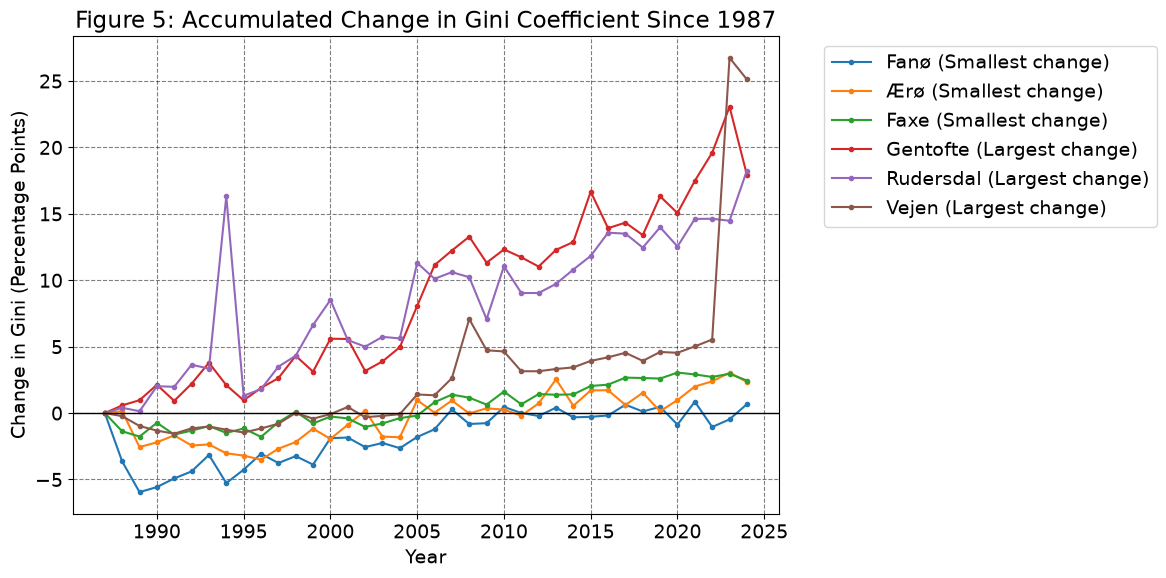

In [65]:
# a. identifying time boundaries
first_year = df_samlet['year'].min()
last_year = df_samlet['year'].max()

# b. Extracting data for the start and end years and setting municipality as index
df_first = df_samlet[df_samlet['year'] == first_year].set_index('KOMMUNEDK')
df_last = df_samlet[df_samlet['year'] == last_year].set_index('KOMMUNEDK')

# c. Calculating the total change in the Gini coefficient
df_change = (df_last['gini'] - df_first['gini']).dropna().sort_values()

# d. Finding the 3 with the smallest- and largest change
smallest_change_munis = df_change.head(3).index.tolist()
largest_change_munis = df_change.tail(3).index.tolist()
selected_munis = smallest_change_munis + largest_change_munis

# e. Illustrating the underlying series of the change over time
plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('tab10') 

for i, muni in enumerate(selected_munis):
    # i. sorting municipality data
    df_muni = df_samlet[df_samlet['KOMMUNEDK'] == muni].sort_values('year').copy()
    
    # ii. calculating the relative change
    baseline_gini = df_muni[df_muni['year'] == first_year]['gini'].values[0]
    df_muni['gini_change'] = df_muni['gini'] - baseline_gini
    
    # iii. assigning label and plotting 
    group = "Smallest change" if muni in smallest_change_munis else "Largest change"
    plt.plot(df_muni['year'], df_muni['gini_change'], 
             color=cmap(i), marker='.', label=f'{muni} ({group})')

# f. Formatting the plot
plt.title(f'Figure 5: Accumulated Change in Gini Coefficient Since {first_year}')
plt.xlabel('Year')
plt.ylabel('Change in Gini (Percentage Points)')
plt.axhline(0, color='black', linewidth=1) # Reference line at zero change
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

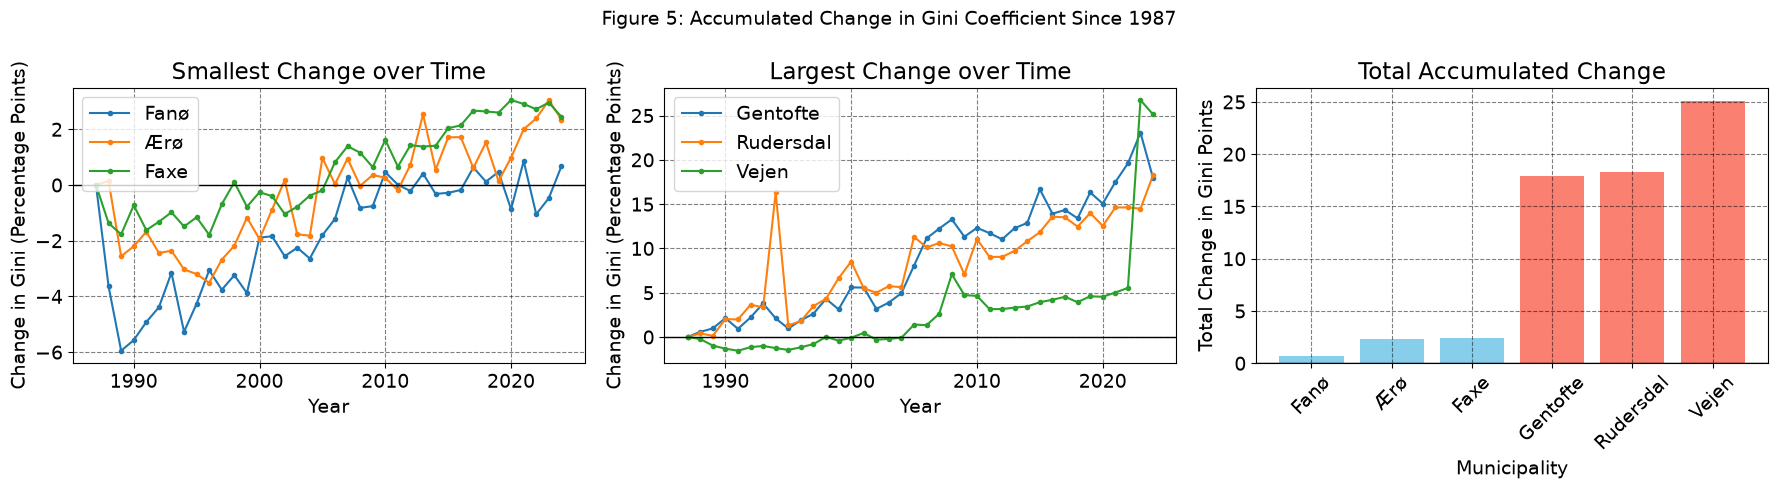

In [66]:
# a. Identifying time boundaries
first_year = df_samlet['year'].min()
last_year = df_samlet['year'].max()

# b. Extracting data for the start and end years and setting municipality as index
df_first = df_samlet[df_samlet['year'] == first_year].set_index('KOMMUNEDK')
df_last = df_samlet[df_samlet['year'] == last_year].set_index('KOMMUNEDK')

# c. Calculating the total change in the Gini coefficient
df_change = (df_last['gini'] - df_first['gini']).dropna().sort_values()

# d. Finding the 3 with the smallest- and largest change
smallest_change_munis = df_change.head(3).index.tolist()
largest_change_munis = df_change.tail(3).index.tolist()
selected_munis = smallest_change_munis + largest_change_munis

# e. Creating a figure with 3 subplots (1 for smallest change, 1 for largest change, 1 for bar overview)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.get_cmap('tab10')

# i. Plotting time series for municipalities with the smallest change
for i, muni in enumerate(smallest_change_munis):
    df_muni = df_samlet[df_samlet['KOMMUNEDK'] == muni].sort_values('year').copy()
    baseline_gini = df_muni[df_muni['year'] == first_year]['gini'].values[0]
    df_muni['gini_change'] = df_muni['gini'] - baseline_gini
    
    axes[0].plot(df_muni['year'], df_muni['gini_change'], 
                 marker='.', label=f'{muni}')

axes[0].set_title('Smallest Change over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Change in Gini (Percentage Points)')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ii. Plotting time series for municipalities with the largest change
for i, muni in enumerate(largest_change_munis):
    df_muni = df_samlet[df_samlet['KOMMUNEDK'] == muni].sort_values('year').copy()
    baseline_gini = df_muni[df_muni['year'] == first_year]['gini'].values[0]
    df_muni['gini_change'] = df_muni['gini'] - baseline_gini
    
    axes[1].plot(df_muni['year'], df_muni['gini_change'], 
                 marker='.', label=f'{muni}')

axes[1].set_title('Largest Change over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Change in Gini (Percentage Points)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# iii. Creating a bar chart summarizing total change for these selected municipalities
subset_change = df_change[selected_munis]
colors = ['skyblue']*3 + ['salmon']*3
axes[2].bar(subset_change.index, subset_change.values, color=colors)

axes[2].set_title('Total Accumulated Change')
axes[2].set_xlabel('Municipality')
axes[2].set_ylabel('Total Change in Gini Points')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, linestyle='--', alpha=0.5)

# f. Formatting the overall figure layout
fig.suptitle(f'Figure 5: Accumulated Change in Gini Coefficient Since {first_year}', fontsize=14)
plt.tight_layout()
plt.show()

We have chosen to include the top 3 municipalities with the smallest and largest change in the Gini Coefficient. Figure 5 display these changes and we see that the largest changes occur for the municipalities that are also amongst the most unequal (cf. figure 4). The three municipalities with the smallest change show an overall stable Gini coefficient even though they are not a part of the 10 leat unequal municipalities. 

Finally, we consider the warning regarding small populations. The graph shows a sudden, massive spike for Vejen around 2023. This abrupt change is highly unlikely to represent a broad structural shift in the municipality. Rather, it perfectly illustrates how the Gini coefficient is not robust to a single very large income in a smaller population. 

**Problem 1.4** Education and Gini coefficent 

Correlation between Gini and Education Share: 0.66


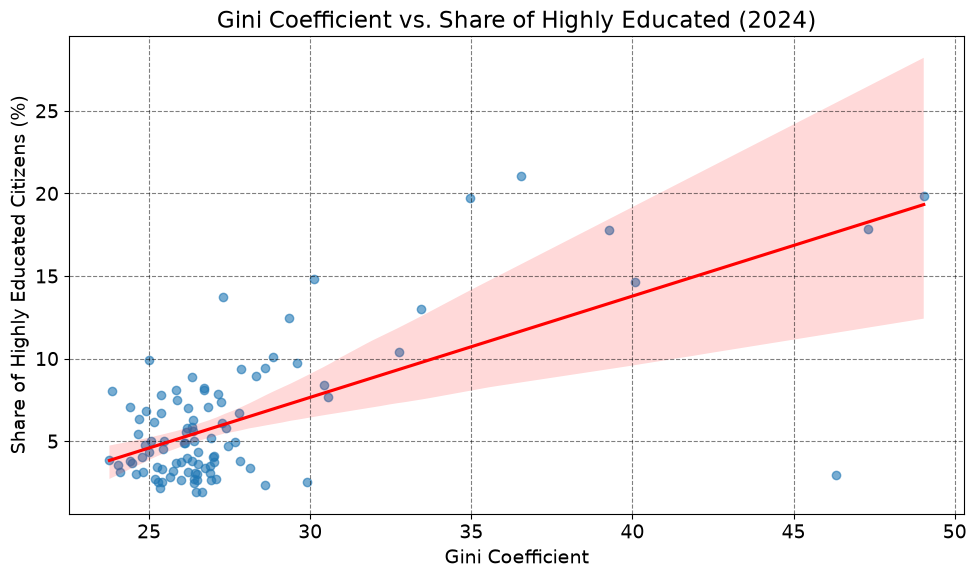

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# a. defining a function to fetch education and population data
def load_education_share(year):
    """ Fetches and calculates the share of highly educated citizens per municipality.
    
    Args:
        year (int/str): The year to fetch data for.
        
    Returns:
        pd.DataFrame: DataFrame containing municipality names and their respective share of highly educated citizens.
    """
    # i. fetching highly educated from active table HFUDD11
    params_edu = {
        'table': 'HFUDD11', 
        'format': 'BULK', 
        'lang': 'en',
        'variables': [
            {'code': 'BOPOMR', 'values': ['*']},         
            {'code': 'KØN', 'values': ['TOT']},
            {'code': 'ALDER', 'values': ['TOT']},
            {'code': 'HERKOMST', 'values': ['TOT']},     # TILFØJET HER
            {'code': 'HFUDD', 'values': ['H70']},        
            {'code': 'TID', 'values': [str(year)]}
        ]
    }    
    df_edu = DstApi('HFUDD11').get_data(params=params_edu)
    
    # ii. error handling for HFUDD11 API response
    if 'INDHOLD' not in df_edu.columns:
        raise ValueError(f"API Error fetching HFUDD11. Danmarks Statistik returned:\n{df_edu.head()}")

    # iii. clean and format education data
    df_edu['INDHOLD'] = pd.to_numeric(df_edu['INDHOLD'], errors='coerce')
    df_edu = df_edu.rename(columns={'INDHOLD': 'highly_educated', 'BOPOMR': 'KOMMUNEDK'})
    
    # iv. fetching total population from FOLK1A
    params_pop = {
        'table': 'FOLK1A', 
        'format': 'BULK', 
        'lang': 'en',
        'variables': [
            {'code': 'OMRÅDE', 'values': ['*']},
            {'code': 'KØN', 'values': ['TOT']},           
            {'code': 'ALDER', 'values': ['IALT']},        
            {'code': 'CIVILSTAND', 'values': ['TOT']},    
            {'code': 'TID', 'values': [f"{int(year)}K4"]} # Use 4th quarter for yearly matching
        ]
    }
    df_pop = DstApi('FOLK1A').get_data(params=params_pop)
    
    # v. error handling for FOLK1A API response
    if 'INDHOLD' not in df_pop.columns:
        raise ValueError(f"API Error fetching FOLK1A. Danmarks Statistik returned:\n{df_pop.head()}")
        
    # vi. cleaning and formating population data
    df_pop['INDHOLD'] = pd.to_numeric(df_pop['INDHOLD'], errors='coerce')
    df_pop = df_pop.rename(columns={'INDHOLD': 'total_population', 'OMRÅDE': 'KOMMUNEDK'})
    
    # vii. merging datasets on municipality
    df_merged = pd.merge(df_edu[['KOMMUNEDK', 'highly_educated']], 
                         df_pop[['KOMMUNEDK', 'total_population']], 
                         on='KOMMUNEDK', how='inner')
    
    # viii. calculating percentage share of highly educated
    df_merged['edu_share_pct'] = (df_merged['highly_educated'] / df_merged['total_population']) * 100
    
    # ix. filtering out aggregated regions and country totals
    exclude_list = ['Region Hovedstaden', 'Region Sjælland', 'Region Syddanmark', 'Region Midtjylland', 'Region Nordjylland', 'Hele landet']
    df_merged = df_merged[~df_merged['KOMMUNEDK'].isin(exclude_list)]
    
    return df_merged[['KOMMUNEDK', 'edu_share_pct']].dropna()

# b. data merging and correlation calculation
df_edu_share = load_education_share(last_year)

df_extended = pd.merge(df_last_year, df_edu_share, on='KOMMUNEDK', how='inner')

correlation = df_extended['gini'].corr(df_extended['edu_share_pct'])
print(f"Correlation between Gini and Education Share: {correlation:.2f}")

# c. plotting scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df_extended, x='gini', y='edu_share_pct', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# d. plot formatting
plt.title(f'Gini Coefficient vs. Share of Highly Educated ({last_year})')
plt.xlabel('Gini Coefficient')
plt.ylabel('Share of Highly Educated Citizens (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The plot displays a clear correlation of 0,66 between the share of highly educated and the Gini coefficient. The positive correlation indicates that a larger share of highly educated in the municipality also increases inequality. This likely arises since higher education raises earings unequally. We see a large cluster in the bottom left with a lower share of highly educated and a lower Gini. The extreme cases of a very large share of highly educated and a very high Gini coefficient are driven by a few very unequal municipalities. These are likely the larger cities with more unequal income distributions. Additionally we have one outlier in the lower right corner, which does not fit the pattern. Here the share of highly educated is around 2,5% with a gini of approximately 46. This is exactly an example of the warning from 1.3, that a small municipality isnt robust to a sinle very large income.

**PROBLEM 2: Simulating the income distribution** 


**2.1) The model is constructed in the attached .py file and imported into the notebook for simulation**



In [68]:
# a. ensuring that all updates to the file model is loaded into the notebook when importing:
%load_ext autoreload
%autoreload 2

# b. Importing the life cycle model from the p2_model.py file:
from p2_model import life_cycle_model

# b. running the model itself:
model = life_cycle_model()
model.sim_life_cycle_model()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**2.1.1) Printing the simulation and analyzing the sanity checks:**

In [69]:
import numpy as np

# a. printing the raw simulation for the first 5 people and first 6 ages
print("Income shape:", model.income.shape)
print(model.income[:5, :6].round(3))


# b. checking education shares
education_shares = np.bincount(
    model.education, minlength=3
) / model.N

expected_education = np.array([0.400, 0.350, 0.250])

print("\nSanity check, Education shares:")
print(
    "Simulated:",
    np.array2string(
        education_shares,
        formatter={'float_kind': lambda x: f"{x:.3f}"}
    )
)
print(
    "Expected: ",
    np.array2string(
        expected_education,
        formatter={'float_kind': lambda x: f"{x:.3f}"}
    )
)

# c. calculating and checking steady-state unemployment
late = [
    np.mean(model.status[model.status[:, t] >= 0, t] == 0)
    for t in range(model.T - 10, model.T)
]

unemployment_sim = np.mean(late)
unemployment_ss = model.sigma / (model.sigma + model.lam)

print("\nSanity check, Unemployment rate:")
print("Simulated: ", round(unemployment_sim, 3))
print("Expected:  ", round(unemployment_ss, 3))


# d. calculating and checking the mean of psi
psi_mean = np.mean(model.psi)

print("\nSanity check, Mean of psi:")
print(f"Simulated: {psi_mean:.3f}")
print(f"Expected:  {1:.3f}")

Income shape: (50000, 47)
[[0.45  0.35  1.026 1.171 1.164 1.134]
 [0.45  0.45  0.45  0.35  1.2   1.157]
 [0.45  0.45  0.45  0.35  0.824 0.773]
 [0.45  0.35  0.35  0.742 0.743 0.702]
 [0.45  0.35  0.35  0.832 0.802 0.836]]

Sanity check, Education shares:
Simulated: [0.403 0.352 0.246]
Expected:  [0.400 0.350 0.250]

Sanity check, Unemployment rate:
Simulated:  0.077
Expected:   0.077

Sanity check, Mean of psi:
Simulated: 1.000
Expected:  1.000


**2.2.2) Time series plot of the mean and different percentiles**


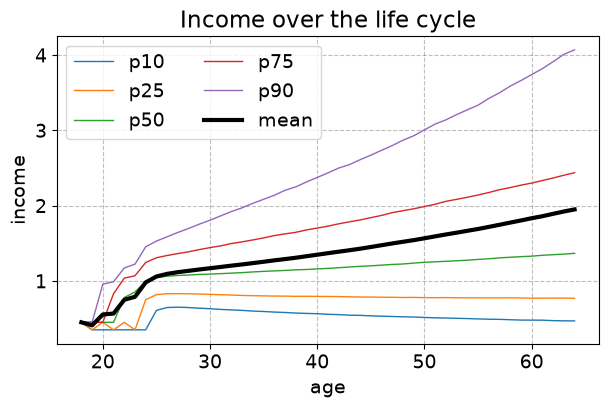

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# a. defining the age range
ages = np.arange(model.age_start, model.age_retire)   # 18..64

# b. calculating mean and percentiles across the simulation
mean_income = model.income.mean(axis=0)
pcts = [10, 25, 50, 75, 90]
P = np.percentile(model.income, pcts, axis=0)        

# c. plotting the income distribution
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

# i. adding percentile lines
for i, p in enumerate(pcts):
    ax.plot(ages, P[i], lw=1, label=f'p{p}')

# ii. adding the mean line and formatting the plot
ax.plot(ages, mean_income, lw=3, color='black', label='mean')
ax.set_xlabel('age')
ax.set_ylabel('income')
ax.set_title('Income over the life cycle')
ax.legend(ncol=2)

**2.2.3) Histogram of income distribution for different age groups**

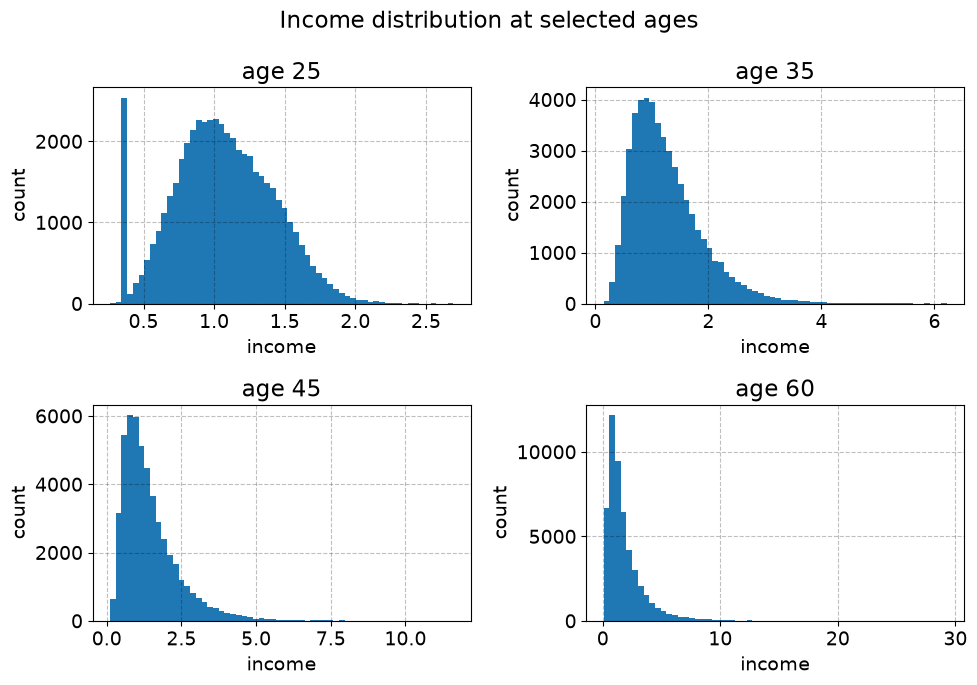

In [71]:
# a. plotting a histogram over the income distribution at selected ages: 
fig = plt.figure(figsize=(10, 7))
for i, age in enumerate([25, 35, 45, 60]):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.hist(model.income[:, age - model.age_start], bins=60)
    ax.set_title(f'age {age}')
    ax.set_xlabel('income')
    ax.set_ylabel('count')
fig.suptitle('Income distribution at selected ages')
fig.tight_layout()

The income distribution changes considerably over the life cycle. At age 25, the distribution is relatively concentrated, with a noticeable spike at low income. 


At ages 35 and 45, the distribution becomes increasingly right-skewed and more dispersed. Most individuals are concentrated at relatively moderate income levels, while a smaller number have substantially higher incomes, creating a long right tail.


By age 60, the right skewness is even more pronounced. Most individuals remain concentrated at lower income levels, while a small number have accumulated very high incomes. Thus, income dispersion increases substantially with age. This is consistent with the model, as differences in education, employment histories, human-capital growth and accumulated shocks cause individual income paths to diverge over time.

**2.3) The Gini coefficient**

In [72]:
# a. Defining the Gini coefficient function.
def gini_coefficient(x):
    """ Calculates the Gini coefficient for a given income distribution.
    
    Args:
        x (array-like): Array of income observations.
        
    Returns:
        float: The calculated Gini coefficient.
    """
    # i. formatting and sort the input array
    x = np.asarray(x, dtype=float)
    x = np.sort(x) #x is the income, that is sorted in ascending order.

    n = len(x) #This is the number of observations in the income distribution.

    gini = (
        2 * np.sum(np.arange(1, n + 1) * x)
        / (n * np.sum(x))
        - (n + 1) / n
    ) #This is how the Gini koefficient is defined. 

    return gini

# b. Making a sanity check for the Gini coefficient function, using a uniform distribution, which should give a Gini coefficient of 0.33:
rng = np.random.default_rng(123)

uniform_test = rng.uniform(0, 1, 1_000_000) ##1.000.000 is the sample size. 

print("Simulated Gini:", gini_coefficient(uniform_test))
print("Theoretical Gini:", 1/3)

Simulated Gini: 0.33313177592344045
Theoretical Gini: 0.3333333333333333


Gini coefficient, full sample: 0.370


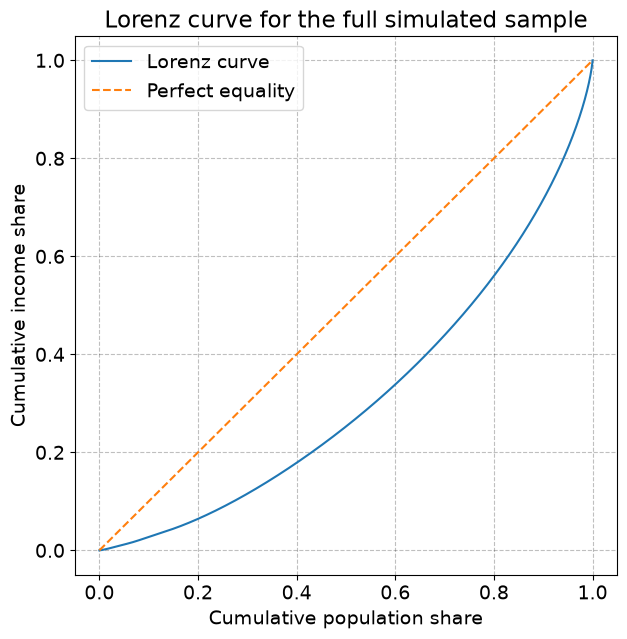

In [73]:
# a. Calculating the Gini coefficient for the full sample of simulated income data:
income_all = model.income.flatten() #This uses the income model, that has been made in p2_model.py.

gini_all = gini_coefficient(income_all)

print(f"Gini coefficient, full sample: {gini_all:.3f}")

# b. defining the Lorenz curve function for the full sample of simulated income data:
def lorenz_curve(x):
    """ Calculates the Lorenz curve coordinates for a given income distribution.
    
    Args:
        x (array-like): Array of income observations.
        
    Returns:
        tuple: Arrays of cumulative population shares and cumulative income shares.
    """
    # i. formatting and sorting the input array
    x = np.asarray(x, dtype=float)
    x = np.sort(x)

    cumulative_income = np.cumsum(x)
    cumulative_income = cumulative_income / cumulative_income[-1]

    population_share = np.arange(1, len(x) + 1) / len(x)

    # ii. calculating cumulative income and population shares and including origin point (0,0) for plotting purposes
    population_share = np.insert(population_share, 0, 0)
    cumulative_income = np.insert(cumulative_income, 0, 0)

    return population_share, cumulative_income

# c. calculating and plotting the Lorenz curve
# i. calculate shares
population_share, income_share = lorenz_curve(income_all)

# ii. creating the plot
plt.figure(figsize=(7, 7))

plt.plot(
    population_share,
    income_share,
    label='Lorenz curve'
)

# iii. add reference line for perfect equality
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect equality'
)

# iv. formatting plots and displaying 
plt.xlabel('Cumulative population share')
plt.ylabel('Cumulative income share')
plt.title('Lorenz curve for the full simulated sample')
plt.legend()

plt.show()

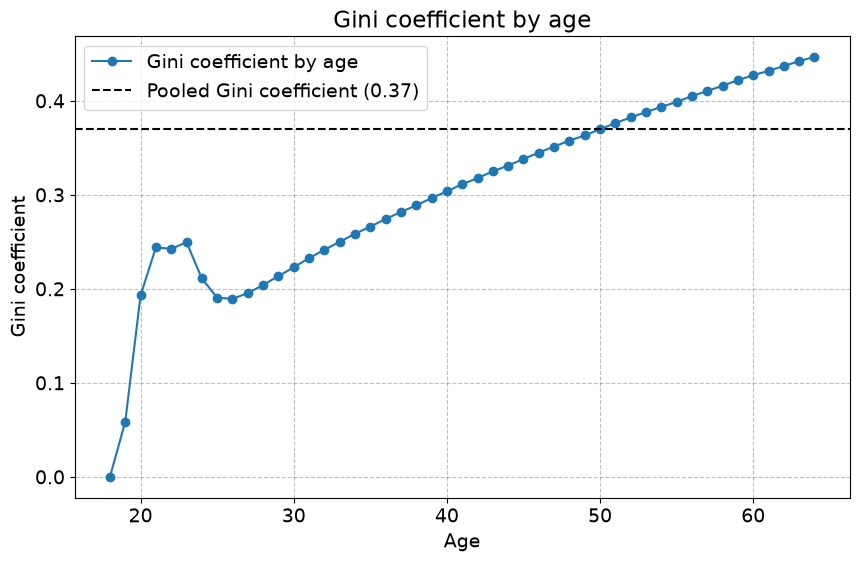

In [74]:
# a. Calculating the gini coefficient for each age in the simulated data and plotting the results:
gini_by_age = np.array([
    gini_coefficient(model.income[:, t])
    for t in range(model.T)
])

# b. defining the age range
ages = np.arange(18, 18 + model.T)

# c. plotting the results
plt.figure(figsize=(10, 6))

# i. plotting the Gini coefficient by age
plt.plot(
    ages,
    gini_by_age,
    marker='o',
    label='Gini coefficient by age'
)

# ii. adding a reference line for the pooled Gini coefficient
plt.axhline(
    y=gini_all, #Using the pooled gini coefficient, that was calculated earlier in the notebook.
    color='black',
    linestyle='--',
    label=f'Pooled Gini coefficient ({gini_all:.2f})'
)

# iii. formatting the plot
plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient by age')
plt.legend()

plt.show()

Inequality rises sharply in the early twenties as individuals with different education lengths enter the labor market at different times. It then decreases slightly as all education groups enter the labor market. From around age 25, inequality increases steadily as differences in human capital, employment histories, and accumulated income shocks grow over the life cycle. Around age 50, within-age inequality exceeds the pooled Gini coefficient of 0.37, showing that income dispersion among older individuals eventually becomes greater than inequality across the pooled sample.

**2.4) What drives the inequality?**

In [75]:
##Making the different models, where we turn off different features of the model to see how they affect the results.

# a. simulating the model with no educational differences
no_education = life_cycle_model(
    se=np.array([0, 0, 0]), #No one goes to school. Meaning that education is euqal to 0. 
    he0=np.array([1.0, 1.0, 1.0]), #This means that the initial human capital is equal for all individuals, regardless of their education level.
    delta_e=np.array([0.02, 0.02, 0.02]) #This means that the growth rate of human capital is equal for all individuals, regardless of their education level.
)

no_education.sim_life_cycle_model()

# b. simulating the model with no shocks to human capital
no_shocks = life_cycle_model(
    sigma_psi=0 # removing variance in human capital shocks
)

no_shocks.sim_life_cycle_model()

# c. simulating the model with no depreciation of human capital
no_depreciation = life_cycle_model(
    delta=0 # setting depreciation rate to zero during unemployment
)

no_depreciation.sim_life_cycle_model()

# d. simulating the model with no unemployment
no_unemployment = life_cycle_model(
    lam=1.0,    # unemployed always find a job
    sigma=0.0,  # employed never lose their job
    delta=0.0   # no human-capital depreciation from unemployment
)

no_unemployment.sim_life_cycle_model()

In [76]:
# a. Calculating Gini coefficients for each model:

# i. defining ages used for the within-age comparison
ages = [25, 35, 45, 60]

# ii. collecting all simulated models into a dictionary
models = {
    "Baseline": model,
    "No education differences": no_education,
    "No human capital shocks": no_shocks,
    "No depreciation": no_depreciation,
    "No unemployment": no_unemployment
}

# b. calculating pooled and age-specific Gini coefficients
results = []

for name, m in models.items():

    # i. calculating pooled Gini across all individuals and ages
    pooled_gini = gini_coefficient(
        m.income.flatten()
    )

    # ii. starting row with model name and pooled Gini
    row = [name, pooled_gini]

    # iii. calculating Gini for each selected age
    for age in ages:

        t_age = age - m.age_start

        age_gini = gini_coefficient(
            m.income[:, t_age]
        )
        
        row.append(age_gini)
    # iv. appending the completed row to the results list
    results.append(row)

# c. Making a table with the results of the different models, where we turn off different features of the model to see how they affect the results.
# i. defining column names
columns = (
    ["Simulation", "Pooled Gini"]
    + [f"Gini at age {age}" for age in ages]
)

# ii. creating the DataFrame
results_df = pd.DataFrame(
    results,
    columns=columns
)
# iii. formatting and displaying the final table
results_df = results_df.round(3)

display(results_df)

,Simulation,Pooled Gini,Gini at age 25,Gini at age 35,Gini at age 45,Gini at age 60
0,Baseline,0.370,0.191,0.266,0.338,0.427
1,No education differences,0.318,0.169,0.250,0.307,0.376
2,No human capital shocks,0.271,0.146,0.168,0.211,0.273
3,No depreciation,0.377,0.185,0.257,0.326,0.414
4,No unemployment,0.375,0.148,0.250,0.323,0.414


The results suggest that shocks to human capital are the most important driver of inequality in the model. Removing these shocks reduces the pooled Gini coefficient from 0.370 to 0.271 and substantially lowers inequality at all selected ages. The relative effect becomes particularly large at older ages, suggesting that human-capital shocks accumulate over the life cycle. Educational differences are the second most important mechanism, as removing them reduces the pooled Gini to 0.318. Removing unemployment or human-capital depreciation has a smaller effect on within-age inequality. Interestingly, both slightly increase the pooled Gini despite reducing inequality within individual age groups. This occurs because the pooled Gini captures both within-age and between-age income differences. Overall, the results indicate that the accumulation of human-capital shocks is the main source of inequality in the simulated economy.

**2.5) Expanding the model with capital and sotchastic returns**

We extend the baseline life-cycle model by introducing capital accumulation and investment return risk. Individuals start with zero financial wealth and save a constant share of their labor or transfer income each period. The accumulated wealth is invested and earns a stochastic annual return.


The expected annual return is 4%, while realized returns differ across individuals and over time due to random investment shocks. Capital income in each period is given by the realized return multiplied by the individual's accumulated wealth. This capital income is included in total income and is simultaneously reinvested, allowing wealth to compound over the life cycle.

The Gini coefficient is calculated based on total income, defined as labor income plus the income generated from accumulated capital.

In [77]:
## Extending the model to include capital accumulation with stochastic returns

# a. setting parameters for capital accumulation
savings_rate = 0.10   # share of labor income saved
r = 0.04              # average annual return on capital
sigma_r = 0.10        # standard deviation of capital return shocks

# b. initializing variables and random number generator
rng = np.random.default_rng(2026)

labor_income = model.income.copy() # Baseline labor/transfer income from the original model

# i. creating empty matrices for capital and total income
capital = np.zeros_like(labor_income)
income_with_capital = np.zeros_like(labor_income)

# ii. setting initial capital to zero
K = np.zeros(model.N)

# c. simulating capital accumulation over time
for t in range(model.T):

    # i. Setting individual stochastic return on capital as a normal distribution with the average return r (4%) and standard deviation sigma_r (10%)
    return_t = rng.normal(
        loc=r,
        scale=sigma_r,
        size=model.N
    )

    # ii. calculating capital income in the current period
    capital_income = return_t * K

    # iii. calculating total income (labor/transfer + capital)
    income_with_capital[:, t] = (
        labor_income[:, t] + capital_income
    )

    # iv. storing current wealth
    capital[:, t] = K

    # v. updating wealth for next period (reinvesting return and saving labor income)
    K = (
        (1 + return_t) * K
        + savings_rate * labor_income[:, t]
    )


# d. calculating and printing Gini coefficients
# i. calculating baseline Gini
gini_baseline = gini_coefficient(
    model.income.flatten()
)
# ii. calculating Gini with capital accumulation
gini_capital = gini_coefficient(
    income_with_capital.flatten()
)

# iii. printing results
print(f"Baseline Gini:     {gini_baseline:.3f}")
print(f"Gini with capital: {gini_capital:.3f}")

Baseline Gini:     0.370
Gini with capital: 0.426


The introduction of capital accumulation with stochastic returns increases the pooled Gini coefficient from 0.370 in the baseline model to 0.426. This suggests that investment risk amplifies income inequality. Individuals receive different realized returns on their accumulated wealth, causing their wealth paths to diverge over time. Since capital returns are reinvested, these differences compound throughout the life cycle. Individuals who experience favorable returns accumulate more wealth and consequently earn more capital income in subsequent periods, while individuals experiencing unfavorable returns follow the opposite path. Thus, stochastic capital returns introduce an additional source of heterogeneity that increases overall income inequality relative to the baseline model.